
# Optimized MFML

This example demonstrates the use of optimized multifidelity machine learning (o-MFML) with a comparison of learning curves for:

1. **Single-Fidelity Kernel Ridge Regression (SF-KRR)**: Trained exclusively on high-fidelity data.
2. **Multi-Fidelity Machine Learning (MFML)**: Uses the default summation of sub-model predictions.
3. **Optimized MFML (o-MFML)**: Uses an Ordinary Least Squares (OLS) optimizer to learn the optimal combination weights for the sub-models based on a validation set.

## Data Setup
- **Training Pool**: 12,288 samples (used to draw nested training subsets).
- **Validation Set**: 712 high-fidelity samples (used strictly to train the o-MFML OLS optimizer).
- **Test Set**: 2,000 samples (used for final MAE evaluation).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mfml_qc.datasets import load_benzene_data
from mfml_qc.utils import build_hierarchy_arrays, top_down_subsetting
from mfml_qc.krr import KRR
from mfml_qc.mfml import ModelMFML

/home/vvinod/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading and Splitting the Dataset
We load the Benzene trajectory and explicitly slice it into the three
required cohorts: Training Pool, Validation Set, and Test Set.



In [2]:
dataset = load_benzene_data()

X_CM = dataset["X_CM"]
data = dataset["energies"]

# Fidelities: LC-DFTB, STO-3G, def2-SVP, def2-TZVP
hierarchy_cols = [2, 3, 6, 7]

# Establish the strict boundaries
train_mask = data[:, 0] < 12288
val_mask = (data[:, 0] >= 12288) & (data[:, 0] < 13000)
test_mask = data[:, 0] >= 13000

# training data
X_train_parent = X_CM[train_mask]
data_train = data[train_mask]

# validation data
X_val = X_CM[val_mask]
y_val_true = data[val_mask, hierarchy_cols[-1]]

# Test Set
X_test = X_CM[test_mask]
y_test_true = data[test_mask, hierarchy_cols[-1]]

## Preparing the Data Arrays
We extract the fully populated hierarchy arrays for the training pool.
We also mean-center the validation targets using the exact same
high-fidelity training mean.



In [3]:
y_trains, indexes, means = build_hierarchy_arrays(data_train, hierarchy_cols)
y_val_centered = y_val_true - means[-1]

## Generating the Learning Curves
We will loop over increasing high-fidelity training capacities. At each step,
we evaluate all three models and average the results over multiple random shuffles.



In [4]:
hf_train_sizes = 2 ** np.arange(1, 9)
navg = 5

# Arrays to store the Mean Absolute Errors (in kcal/mol)
sf_maes = np.zeros((len(hf_train_sizes), navg))
mfml_maes = np.zeros((len(hf_train_sizes), navg))
omfml_maes = np.zeros((len(hf_train_sizes), navg))

for n in range(navg):

    for s_idx, hf_size in enumerate(hf_train_sizes):

        # Define the target hierarchy sizes: [8x, 4x, 2x, 1x]
        n_trains_target = [hf_size * 8, hf_size * 4, hf_size * 2, hf_size]

        # Perform top-down cascade to guarantee nestedness
        subset_y, subset_idx = top_down_subsetting(
            y_trains, indexes, n_trains_target, seed=42 + n
        )

        # single fidelity KRR
        X_sf = X_train_parent[subset_idx[-1][:, 0]]
        y_sf = subset_y[-1]

        krr_sf = KRR(kernel_type="matern", sigma=715.0, reg=1e-9)
        krr_sf.train(X_sf, y_sf)

        preds_sf = krr_sf.predict(X_test) + means[-1]
        sf_maes[s_idx, n] = np.mean(np.abs(preds_sf - y_test_true)) * 23

        # basic MFML
        mfml_model = ModelMFML(kernel="matern", sigma=715.0, reg=1e-9, p_bar=False)
        mfml_model.train(
            X_train_parent=X_train_parent, y_trains=subset_y, indexes=subset_idx
        )

        preds_mfml = mfml_model.predict(X_test=X_test, optimiser="default") + means[-1]
        mfml_maes[s_idx, n] = np.mean(np.abs(preds_mfml - y_test_true)) * 23

        # o-MFML
        preds_omfml = (
            mfml_model.predict(
                X_test=X_test, X_val=X_val, y_val=y_val_centered, optimiser="OLS"
            )
            + means[-1]
        )

        omfml_maes[s_idx, n] = np.mean(np.abs(preds_omfml - y_test_true)) * 23

Extracting X_trains:   0%|                                                                                                         | 0/4 [00:00<?, ?it/s]

Extracting upper y_trains:   0%|                                                                                                   | 0/4 [00:00<?, ?it/s]

Extracting lower y_trains:   0%|                                                                                                   | 0/3 [00:00<?, ?it/s]

Training upper ML models...:   0%|                                                                                                 | 0/4 [00:00<?, ?it/s]

Training lower ML models:   0%|                                                                                                    | 0/3 [00:00<?, ?it/s]

...

Upper MFML predictions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  4.85it/s]

Lower MFML predictions:   0%|                                                                                                      | 0/3 [00:00<?, ?it/s]

Lower MFML predictions:  33%|███████████████████████████████▎                                                              | 1/3 [00:00<00:00,  3.53it/s]

Lower MFML predictions:  67%|██████████████████████████████████████████████████████████████▋                               | 2/3 [00:00<00:00,  4.79it/s]

Lower MFML predictions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  6.06it/s]

## Visualizing the Comparison
Finally, we plot the averaged learning curves to see how standard MFML
dominates at extremely low data regimes, and how o-MFML optimizes the
weights as the training set size increases.



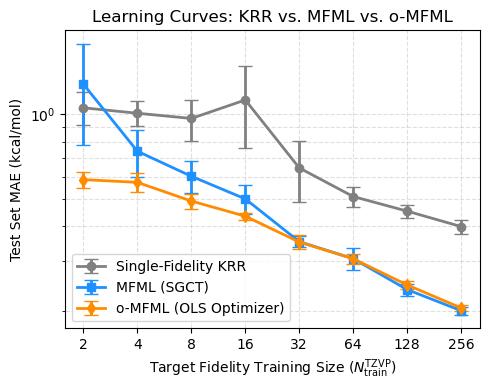

In [5]:
# Calculate means over the random shuffles
mean_sf = np.mean(sf_maes, axis=1)
mean_mfml = np.mean(mfml_maes, axis=1)
mean_omfml = np.mean(omfml_maes, axis=1)

# Calculate standard deviations for error bars
std_sf = np.std(sf_maes, axis=1)
std_mfml = np.std(mfml_maes, axis=1)
std_omfml = np.std(omfml_maes, axis=1)

plt.figure(figsize=(5, 4))

# Plotting the three curves
plt.errorbar(
    hf_train_sizes,
    mean_sf,
    yerr=std_sf,
    fmt="o-",
    color="gray",
    capsize=5,
    linewidth=2,
    label="Single-Fidelity KRR",
)

plt.errorbar(
    hf_train_sizes,
    mean_mfml,
    yerr=std_mfml,
    fmt="s-",
    color="dodgerblue",
    capsize=5,
    linewidth=2,
    label="MFML (SGCT)",
)

plt.errorbar(
    hf_train_sizes,
    mean_omfml,
    yerr=std_omfml,
    fmt="d-",
    color="darkorange",
    capsize=5,
    linewidth=2,
    label="o-MFML (OLS Optimizer)",
)

# Formatting the plot
plt.xscale("log", base=2)
plt.yscale("log")
plt.xticks(hf_train_sizes, labels=[str(s) for s in hf_train_sizes])

plt.xlabel(r"Target Fidelity Training Size ($N_{\mathrm{train}}^{\mathrm{TZVP}}$)")
plt.ylabel("Test Set MAE (kcal/mol)")
plt.title("Learning Curves: KRR vs. MFML vs. o-MFML")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()